In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [52]:
df=pd.read_csv('../concrete_data.csv')

In [53]:
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [54]:
df.shape

(1030, 9)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [56]:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [57]:
df.isnull().mean()*100

cement                           0.0
blast_furnace_slag               0.0
fly_ash                          0.0
water                            0.0
superplasticizer                 0.0
coarse_aggregate                 0.0
fine_aggregate                   0.0
age                              0.0
concrete_compressive_strength    0.0
dtype: float64

In [58]:
# for col in df.columns:
#     plt.figure(figsize=(10,5))
#     plt.subplot(121)
#     sns.distplot(x=df[col])
#     plt.subplot(122)
#     sns.boxplot(x=df[col])


In [59]:
# corr=df.corr()
# sns.heatmap(corr,annot=True)

In [60]:
# for col in df.columns:
#     plt.figure(figsize=(10,5))
#     sns.histplot(x=df[col])

In [61]:
# sns.pairplot(df)

In [62]:
df['water_cement_ratio'] = df['water'] / df['cement']

In [63]:
df['total_binder'] = df['cement'] + df['fly_ash'] + df['blast_furnace_slag']

In [64]:
df.columns

Index(['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer',
       'coarse_aggregate', 'fine_aggregate ', 'age',
       'concrete_compressive_strength', 'water_cement_ratio', 'total_binder'],
      dtype='object')

In [65]:
df.drop(columns=['coarse_aggregate','fine_aggregate '],inplace=True)

In [66]:
from sklearn.model_selection import train_test_split

x=df.drop(columns='concrete_compressive_strength')
y=df['concrete_compressive_strength']

Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

mask = (y >= Q1 - 1.5*IQR) & (y <= Q3 + 1.5*IQR)

x = x[mask]
y = y[mask]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [67]:
x_train.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,age,water_cement_ratio,total_binder
625,307.0,0.0,0.0,193.0,0.0,90,0.628664,307.0
268,212.0,0.0,124.8,159.0,7.8,100,0.750000,336.8
592,382.5,0.0,0.0,185.7,0.0,28,0.485490,382.5
471,446.0,24.0,79.0,162.0,11.6,28,0.363229,549.0
653,102.0,153.0,0.0,192.0,0.0,90,1.882353,255.0


In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [69]:
trf=(
    'transform',Pipeline([
    ('scaling',StandardScaler())
]),x_train.columns
)

In [70]:
transformer=ColumnTransformer(transformers=[trf],remainder="passthrough")

In [71]:
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error,mean_squared_error

# SVM - Regressor

In [78]:
from sklearn.svm import SVR
svr=SVR(kernel="rbf",C= 100,epsilon=0.1,gamma= 0.1)
model=Pipeline([
    ('transformer',transformer),
    ('clf',svr)
])
model.fit(x_train,y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('transform',
                                                  Pipeline(steps=[('scaling',
                                                                   StandardScaler())]),
                                                  Index(['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer',
       'age', 'water_cement_ratio', 'total_binder'],
      dtype='object'))])),
                ('clf', SVR(C=100, gamma=0.1))])

In [80]:
y_pred=model.predict(x_test)
print(root_mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

5.153183093334876
3.8589166583484475
26.555295993432406
0.8803891163464381


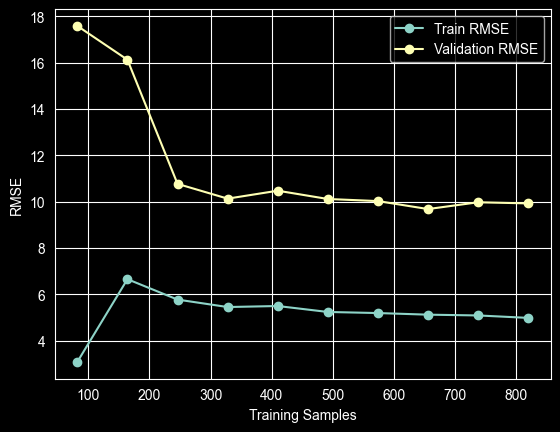

In [81]:
import numpy as np
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    model,
    x,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.plot(train_sizes, train_rmse, marker='o', label='Train RMSE')
plt.plot(train_sizes, val_rmse, marker='o', label='Validation RMSE')
plt.xlabel("Training Samples")
plt.ylabel("RMSE")
plt.legend()
plt.show()

In [75]:
from sklearn import set_config
set_config(display='text')


In [76]:
# from sklearn.model_selection import GridSearchCV
#
# param_grid = {
#     'clf__C': [10, 50, 100, 500, 1000],
#     'clf__gamma': [0.1, 0.01, 0.001, 0.0005],
#     'clf__epsilon': [0.1, 0.01]
# }
#
# grid=GridSearchCV(model,param_grid=param_grid,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1)
#
# grid.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('transform',
                                                                         Pipeline(steps=[('scaling',
                                                                                          StandardScaler())]),
                                                                         Index(['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer',
       'age', 'water_cement_ratio', 'total_binder'],
      dtype='object'))])),
                                       ('clf', SVR())]),
             n_jobs=-1,
             param_grid={'clf__C': [10, 50, 100, 500, 1000],
                         'clf__epsilon': [0.1, 0.01],
                         'clf__gamma': [0.1, 0.01, 0.001, 0.0005]},
             scoring='neg_root_mean_squared_error

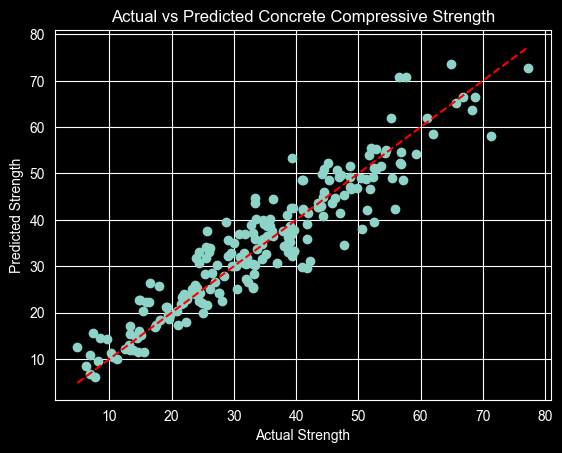

In [82]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.title("Actual vs Predicted Concrete Compressive Strength")
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.show()